In [1]:
import pandas as pd
df=pd.read_excel('data/raisin_dataset.xlsx')

In [2]:
df.sample(5)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
93,67044,361.255372,238.226446,0.751757,68626,0.756944,989.016,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen
877,126019,520.680034,316.189875,0.794501,130948,0.694511,1422.242,Besni
493,72606,424.472024,223.232633,0.850542,76975,0.683853,1117.107,Besni
148,39509,286.231563,180.437360,0.776279,41446,0.722972,790.531,Kecimen


In [3]:
df.columns

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'Extent', 'Perimeter', 'Class'],
      dtype='str')

In [9]:
x=df.drop('Class',axis=1)
y=df['Class']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=45,test_size=0.2)

In [12]:
from sklearn.svm import SVC

model=SVC(kernel='rbf')
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

from sklearn.metrics import classification_report,confusion_matrix
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

       Besni       0.84      0.72      0.77        93
     Kecimen       0.74      0.85      0.79        87

    accuracy                           0.78       180
   macro avg       0.79      0.79      0.78       180
weighted avg       0.79      0.78      0.78       180



<Axes: >

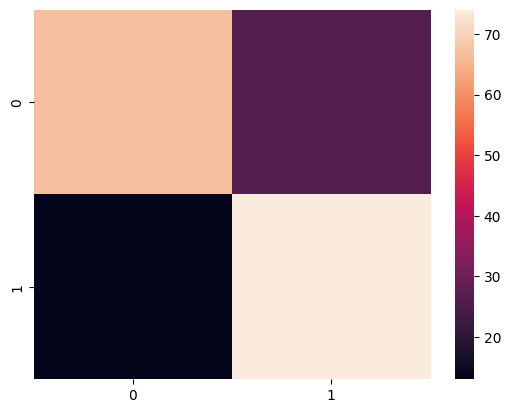

In [14]:
import seaborn as sns
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm)

# Ensemble

## voting classifier

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

log_model=LogisticRegression()
svc_model=SVC(kernel='rbf',probability=True)
tree_model=DecisionTreeClassifier()

vc=VotingClassifier(
    estimators=[
        ('lr',log_model),
        ('svc',svc_model),
        ('tree',tree_model)
    ]
,voting='soft') #deafult is 'hard'

vc.fit(x_train,y_train)
y_pred=vc.predict(x_test)

from sklearn.metrics import classification_report,confusion_matrix
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

       Besni       0.88      0.85      0.86        93
     Kecimen       0.84      0.87      0.86        87

    accuracy                           0.86       180
   macro avg       0.86      0.86      0.86       180
weighted avg       0.86      0.86      0.86       180



C:\Users\Jeevan kumar\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Voting Regressor

In [ ]:
x_train=pd.get_dummies(x_train)
y_train=pd.get_dummies(y_train)

In [34]:
x_test=pd.get_dummies(x_test)
y_test=pd.get_dummies(y_test)

In [37]:
y_test.drop('Kecimen',axis=1,inplace=True)

In [33]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor

rid_model=Ridge(alpha=0.1)
dt_model=DecisionTreeRegressor()

vr=VotingRegressor(
    estimators=[
        ('ridge',rid_model),
        ('tree',dt_model)
    ]
)

vr.fit(x_train,y_train)

C:\Users\Jeevan kumar\AppData\Roaming\Python\Python313\site-packages\sklearn\ensemble\_voting.py:676: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('ridge', ...), ('tree', ...)]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples

In [38]:
vr.score(x_test,y_test)

0.5277789482216968

## Weighted average

In [40]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

lr = LinearRegression()
ridge = Ridge(alpha=0.1)
tree = DecisionTreeRegressor(random_state=42)

vr = VotingRegressor(
    estimators=[
        ('lr', lr),
        ('ridge', ridge),
        ('tree', tree)
    ]
    ,weights=[0.7,0.3,0.5]
)

vr.fit(x_train, y_train)

y_pred = vr.predict(x_test)

print("R² Score:", vr.score(x_test, y_test))

R² Score: 0.5513795833467021


C:\Users\Jeevan kumar\AppData\Roaming\Python\Python313\site-packages\sklearn\ensemble\_voting.py:676: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
